# 1. Import Library

In [1]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## Read Dataset

In [2]:
# Fetch the MNIST dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
assert mnist is not None, "Data and target are not found"

X_original = mnist.data
y_original = mnist.target

# Rescale to [0, 1.0]
X_original = X_original / 255
X_original = X_original.reshape(-1, 28, 28)


X_original.shape, y_original.shape

((70000, 28, 28), (70000,))

## Prepare train loader

In [3]:
%reload_ext autoreload
from src.data_processing import get_data_loader

loader = get_data_loader(train_data=X_original, batch_size=64)

len(loader)

1094

# 2. Evaluate TopoAE model

## 2.1 Load Model

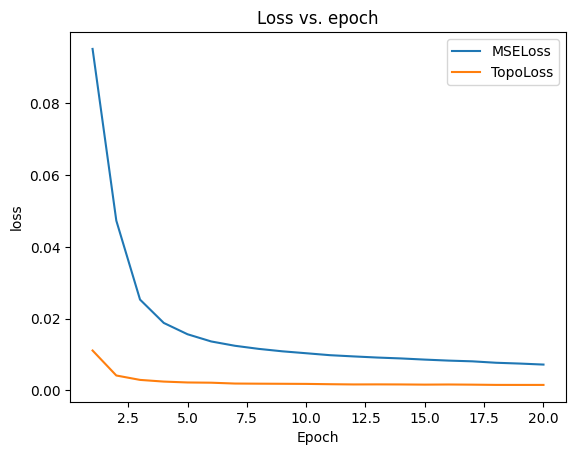

In [4]:
from src.models import ModelState
from src.autoencoder import CNNAutoencoder
import torch

topoae_model = ModelState(CNNAutoencoder())
topoae_model.load_model(model_name="TopoAE_v0_3-7_full")

topoae_model.visualize_loss()

## 2.2 Compressed the data

In [5]:
from src.data_processing import get_data_loader

loader = get_data_loader(train_data=X_original, batch_size=32, shuffle=False)
X_compressed_scaled = topoae_model.model.encode_dataset(loader, device=torch.device('cpu'))


X_compressed_scaled.shape, y_original.shape

((70000, 64), (70000,))

## 2.3 Evaluate model on Downstream Task

### Split data into training vs. testing set

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_compressed_scaled, y_original, test_size=0.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((56000, 64), (14000, 64), (56000,), (14000,))

### A. Logistic Regression model

Training Logistic Regression: 100%|██████████| 20/20 [00:05<00:00,  3.74it/s, Loss=0.295]

Model accuracy on test set:  0.9118571428571428


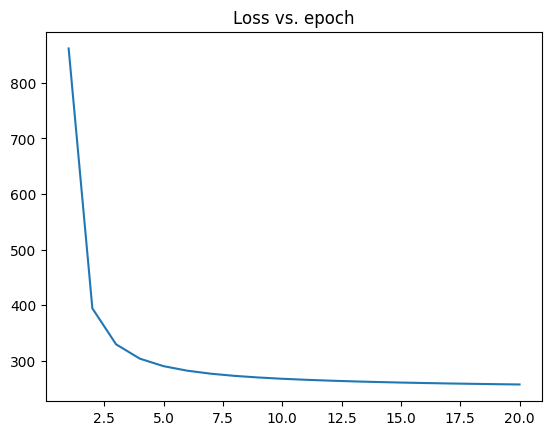

In [19]:
%reload_ext autoreload
from src.downstream_tasks import LogisticRegModel
from sklearn.metrics import accuracy_score

num_epochs = 20
logistic_model = LogisticRegModel(X_train.shape[1], 10, seed=42)

log_loss = logistic_model.fit(X_train, y_train, num_epochs=num_epochs, lr=1e-3)
epoch_plot = list(range(1, num_epochs+1))
topoae_logistic = logistic_model.eval(X_test, y_test, accuracy_score)

print("Model accuracy on test set: ", topoae_logistic)

plt.plot(epoch_plot, log_loss)
plt.title("Loss vs. epoch")
plt.show()

### B. Naive Bayes Model

In [20]:
from src.downstream_tasks import NaiveBayesModel
from sklearn.metrics import accuracy_score

naive_bayes_model = NaiveBayesModel()
naive_bayes_model.fit(X_train, y_train)

topoae_nb = naive_bayes_model.eval(X_test, y_test, accuracy_score)

print("Naive Bayes model accuracy on test set: ", topoae_nb)

Naive Bayes model accuracy on test set:  0.8717142857142857


### C. Neural Network

In [21]:
from src.downstream_tasks import NeuralNetworkModel

nn_model = NeuralNetworkModel(input_size=X_train.shape[1], output_size=10, hidden_layers=[32, 16], seed=42, device=torch.device('mps'))
nn_model.fit(X_train, y_train, num_epochs=5, lr=1e-3)

topoae_nn = nn_model.eval(X_test, y_test, accuracy_score)

print("Neural Network model accuracy on test set: ", topoae_nn)

Training Neural Network: 100%|██████████| 5/5 [00:01<00:00,  2.74it/s, Loss=0.00177]

Neural Network model accuracy on test set:  0.9437857142857143


## 3. Test on original AE

## 3.1 Load model

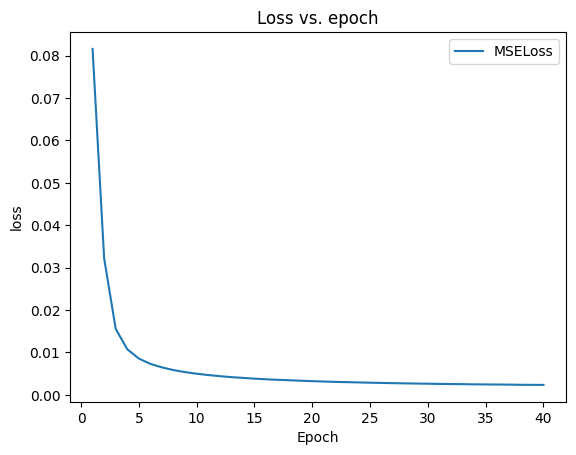

In [10]:
import torch

ae_model = ModelState(CNNAutoencoder())
ae_model.load_model(model_name="AE_v0_12-7")

ae_model.visualize_loss()

## 3.2 Prepare data

In [11]:
from src.data_processing import get_data_loader

loader = get_data_loader(train_data=X_original, batch_size=32, shuffle=False)
X_compressed_scaled = ae_model.model.encode_dataset(loader, device=torch.device('cpu'))

X_train, X_test, y_train, y_test = train_test_split(X_compressed_scaled, y_original, test_size=0.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((56000, 64), (14000, 64), (56000,), (14000,))

## 3.3 Evaluate model on downstream task

### A. Logistic

Training Logistic Regression: 100%|██████████| 20/20 [00:05<00:00,  3.70it/s, Loss=0.295]

Model accuracy on test set:  0.9118571428571428


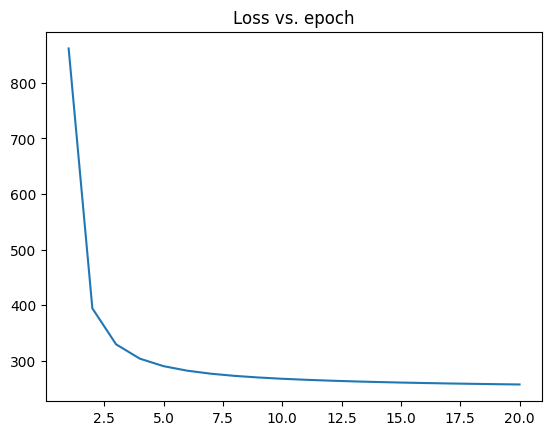

In [22]:
%reload_ext autoreload
from src.downstream_tasks import LogisticRegModel
from sklearn.metrics import accuracy_score

num_epochs = 20
logistic_model = LogisticRegModel(X_train.shape[1], 10, seed=42)

log_loss = logistic_model.fit(X_train, y_train, num_epochs=num_epochs, lr=1e-3)
epoch_plot = list(range(1, num_epochs+1))

ae_logistic = logistic_model.eval(X_test, y_test, accuracy_score)
    
print("Model accuracy on test set: ", logistic_model.eval(X_test, y_test, accuracy_score))

plt.plot(epoch_plot, log_loss)
plt.title("Loss vs. epoch")
plt.show()

### B. Naive Bayes Model

In [28]:
from src.downstream_tasks import NaiveBayesModel
from sklearn.metrics import accuracy_score

naive_bayes_model = NaiveBayesModel()
naive_bayes_model.fit(X_train, y_train)

ae_nb = naive_bayes_model.eval(X_test, y_test, accuracy_score)

print("Naive Bayes model accuracy on test set: ", ae_nb)

Naive Bayes model accuracy on test set:  0.8717142857142857


### C. Neural Network

In [29]:
from src.downstream_tasks import NeuralNetworkModel

nn_model = NeuralNetworkModel(input_size=X_train.shape[1], output_size=10, hidden_layers=[32, 16], seed=42, device=torch.device('mps'))
nn_model.fit(X_train, y_train, num_epochs=5, lr=1e-3)

ae_nn = nn_model.eval(X_test, y_test, accuracy_score)

print("Neural Network model accuracy on test set: ", ae_nb)

Training Neural Network:   0%|          | 0/5 [00:00<?, ?it/s]

Training Neural Network: 100%|██████████| 5/5 [00:01<00:00,  2.56it/s, Loss=0.00177]

Neural Network model accuracy on test set:  0.8717142857142857


## 4. Test on PCA

### 4.1 Reload model and prepare dataset

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=64)
X_flatten = X_original.reshape(X_original.shape[0], -1)

X_reduced = pca.fit_transform(X_flatten)

X_train, X_test, y_train, y_test = train_test_split(X_reduced, y_original, test_size=0.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((56000, 64), (14000, 64), (56000,), (14000,))

## 4.2 Evaluate model on downstream task

### A. Logistic

Training Logistic Regression: 100%|██████████| 20/20 [00:05<00:00,  3.66it/s, Loss=0.295]

Model accuracy on test set:  0.9118571428571428


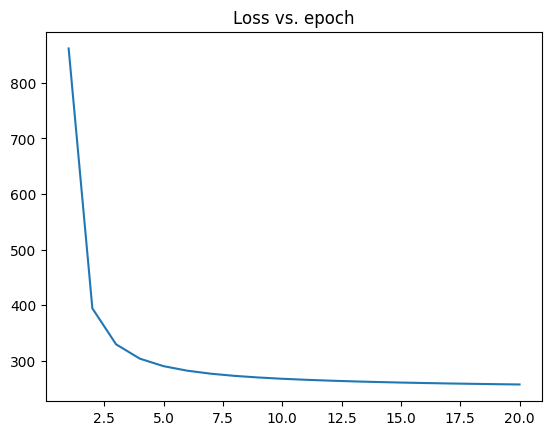

In [25]:
%reload_ext autoreload
from src.downstream_tasks import LogisticRegModel
from sklearn.metrics import accuracy_score

num_epochs = 20
logistic_model = LogisticRegModel(X_train.shape[1], 10, seed=42)

log_loss = logistic_model.fit(X_train, y_train, num_epochs=num_epochs, lr=1e-3)
epoch_plot = list(range(1, num_epochs+1))

pca_logistic = logistic_model.eval(X_test, y_test, accuracy_score)
print("Model accuracy on test set: ", pca_logistic)

plt.plot(epoch_plot, log_loss)
plt.title("Loss vs. epoch")
plt.show()

### B. Naive Bayes Model

In [26]:
from src.downstream_tasks import NaiveBayesModel
from sklearn.metrics import accuracy_score

naive_bayes_model = NaiveBayesModel()
naive_bayes_model.fit(X_train, y_train)

pca_nb = naive_bayes_model.eval(X_test, y_test, accuracy_score)

print("Naive Bayes model accuracy on test set: ", pca_nb)

Naive Bayes model accuracy on test set:  0.8717142857142857


### C. Neural Network

In [27]:
from src.downstream_tasks import NeuralNetworkModel

nn_model = NeuralNetworkModel(input_size=X_train.shape[1], output_size=10, hidden_layers=[32, 16], seed=42, device=torch.device('mps'))
nn_model.fit(X_train, y_train, num_epochs=5, lr=1e-3)

pca_nn = nn_model.eval(X_test, y_test, accuracy_score)

print("Neural Network model accuracy on test set: ", pca_nn)

Training Neural Network: 100%|██████████| 5/5 [00:01<00:00,  2.54it/s, Loss=0.00177]

Neural Network model accuracy on test set:  0.9437857142857143


In [32]:
from IPython.display import Markdown

result = f"""
# Evaluation Results

| | TopoAE | AE | PCA |
|-| - | - | - |
| Naive Bayes | {topoae_nb:.4f} | {ae_nb:.4f} | {pca_nb:.4f} |
| Logistic | {topoae_logistic:.4f} | {ae_logistic:.4f} | {pca_logistic:.4f} |
| Neural Network | {topoae_nn:.4f} | {ae_nn:.4f} | {pca_nn:.4f} |
"""

Markdown(result)


# Evaluation Results

| | TopoAE | AE | PCA |
|-| - | - | - |
| Naive Bayes | 0.8717 | 0.8717 | 0.8717 |
| Logistic | 0.9119 | 0.9119 | 0.9119 |
| Neural Network | 0.9438 | 0.9391 | 0.9438 |


# 5. Visualize using t-SNE

In [68]:
from sklearn.manifold import TSNE

color_map = {
    0: 'red',
    1: 'blue',
    2: 'green',
    3: 'orange',
    4: 'purple',
    5: 'brown',
    6: 'pink',
    7: 'gray',
    8: 'cyan',
    9: 'magenta'
}

def embedding_tsne(X, y, perplexity=30, n_components=2, random_state=42):
    tsne = TSNE(n_components=n_components, perplexity=perplexity, random_state=random_state)
    X_embedded = tsne.fit_transform(X, y)

    cdict = {i: color_map[i] for i in range(10)}
    
    fig, ax = plt.subplots()
    for i in range(10):
        idxes = [idx for idx, y_plot in enumerate(y) if y_plot == str(i)]
        ax.scatter(x=X_embedded[idxes, 0], y=X_embedded[idxes, 1], color=cdict[i], label=f'Class {i}', s=5)

    ax.legend()
    ax.set_title('t-SNE Visualization')
    ax.set_xlabel('t-SNE Component 1')
    ax.set_ylabel('t-SNE Component 2')
    plt.show()

## A. TopoAE Model

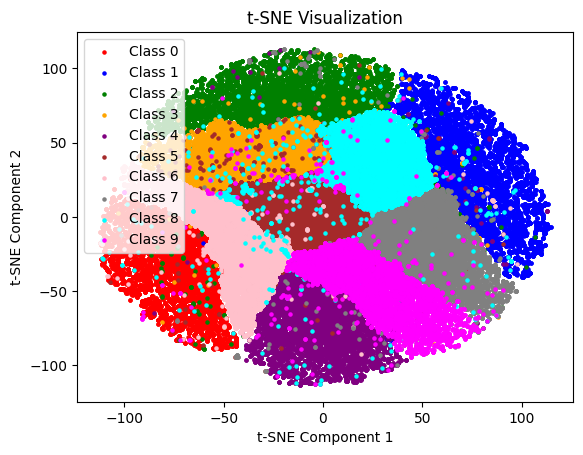

In [ ]:
loader = get_data_loader(train_data=X_original, batch_size=32, shuffle=False)
X_compressed_scaled = topoae_model.model.encode_dataset(loader, device=torch.device('cpu'))

embedding_tsne(X_compressed_scaled, y_original, perplexity=3, n_components=2)

## B. AE Model

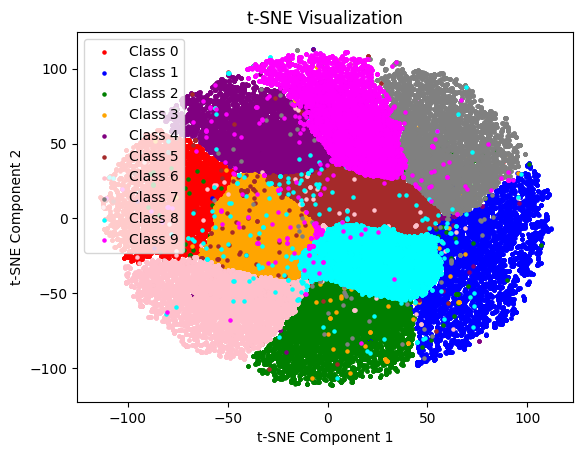

In [71]:
loader = get_data_loader(train_data=X_original, batch_size=32, shuffle=False)
X_compressed_scaled = ae_model.model.encode_dataset(loader, device=torch.device('cpu'))

embedding_tsne(X_compressed_scaled, y_original, perplexity=3, n_components=2)

## C. Original

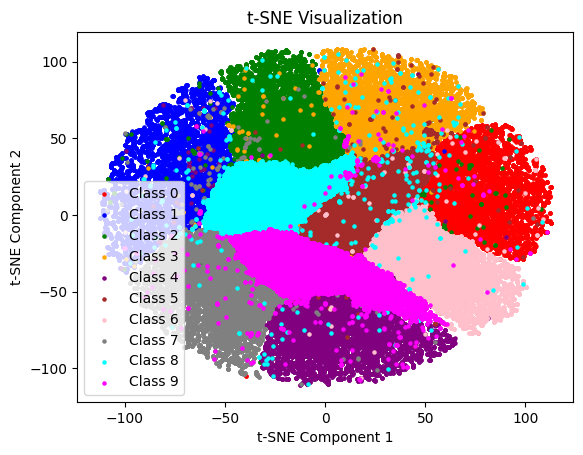

In [72]:
X_flatten = X_original.reshape(X_original.shape[0], -1)

embedding_tsne(X_flatten, y_original, perplexity=3, n_components=2)